# Solve ILRS problem using Gurobi PoolSearch 

In [1]:
from solve_gurobi_poolsearch_funcs import * 

In [2]:
# Build and solve the model using Gurobi's PoolSearch feature

# Set up paths
script_dir = Path().parent
data_filepath = script_dir / ".." / "data"
result_dir = script_dir / "result_gurobi"


In [ ]:
# Build model
m_poolsearch, vars_poolsearch = build_discrete_ip_model(
    str(data_filepath), 
    use_quad_constraints=True
)

# Solve with pool search
result_dict = solve_gurobi_pool(
    m=m_poolsearch,
    vars_dict=vars_poolsearch,
    pool_search_mode=2,
    pool_solutions=252,
    output_dir=result_dir,
    verbose=True,
    save=True
)

In [3]:
result_dir = script_dir / "result_gurobi" / "replicates"
n = [100, 150, 200, 252, 300, 500]

for num_solutions in n:
    for replicate in range(5):
        m_poolsearch, vars_poolsearch = build_discrete_ip_model(
            str(data_filepath),
            use_quad_constraints=True
        )

        result_dict = solve_gurobi_pool(
            m=m_poolsearch,
            vars_dict=vars_poolsearch,
            pool_search_mode=2,
            pool_solutions=num_solutions,
            output_dir=result_dir,
            verbose=False,
            save=True
        )


Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-21
Read LP format model from file /tmp/tmpw625f39j.lp
Reading time = 0.00 seconds
objective: 38 rows, 24 columns, 88 nonzeros
Set parameter PoolSearchMode to value 2
Set parameter PoolSolutions to value 100
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: 13th Gen Intel(R) Core(TM) i7-1365U, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
PoolSolutions  100
PoolSearchMode  2



Optimize a model with 38 rows, 24 columns and 88 nonzeros
Model fingerprint: 0xa1280c40
Model has 12 quadratic objective terms
Variable types: 0 continuous, 24 integer (24 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [8e+00, 2e+01]
  QObjective range [6e-01, 3e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective 27.1600000
Presolve removed 7 rows and 7 columns
Presolve time: 0.00s
Presolved: 43 rows, 29 columns, 110 nonzeros
Variable types: 0 continuous, 29 integer (29 binary)
Found heuristic solution: objective 24.6200000
Found heuristic solution: objective 21.7000000

Root relaxation: objective 1.880000e+01, 8 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0   18.80000    0    2   21.70000   18.80000  13.4%     -    0s
H    0     0 

# Import Gurobi PoolSearch Run for Analysis

In [3]:
# Load data
import_dir = './result_gurobi'
gpool_path = os.path.join(import_dir, 'ilrs_gpool_n228_20260126_101442.json')

gpool_data = load_gurobi_pool_results(gpool_path)
run_info = gpool_data['run_info']
solutions = gpool_data['solutions']

# Print run info
print(f"Loaded {len(solutions)} solutions\n")
print_run_info(run_info)

# # Create flattened DataFrame
gpool_flat = create_flattened_dataframe(solutions)

# Group by objective value
obj_groups = group_by_objective(gpool_flat)

print(f"Number of unique objective values: {len(obj_groups)}")

# Analyze solutions to distinguish duplicates vs same objective
print_solution_analysis(gpool_flat)

Loaded 228 solutions

Run Info:
  Model: objective
  Variables: 24
  Constraints: 38
  Solve Time: 62.95 seconds
  Solutions Found: 228
Number of unique objective values: 78

SOLUTION ANALYSIS

1. DUPLICATE SOLUTIONS (same y/z variable values AND same objective):
   Total solutions with duplicate y/z variable combinations: 159
   Unique y/z variable combinations: 69

   Duplicate groups (same y/z variables, same objective):
     Objective 45.26: 7 solutions (IDs: [66, 67, 68, 69, 70, 71, 72])
     Objective 45.40: 7 solutions (IDs: [74, 75, 76, 77, 78, 79, 80])
     Objective 45.46: 7 solutions (IDs: [81, 82, 83, 84, 85, 86, 87])
     Objective 45.64: 7 solutions (IDs: [90, 91, 92, 93, 94, 95, 96])
     Objective 46.02: 7 solutions (IDs: [97, 98, 99, 100, 101, 102, 103])
     Objective 46.08: 7 solutions (IDs: [104, 105, 106, 107, 108, 109, 110])
     Objective 46.24: 7 solutions (IDs: [111, 112, 113, 114, 115, 116, 117])
     Objective 46.32: 7 solutions (IDs: [118, 119, 120, 121, 122

{'analysis': {'duplicate_solutions': {47.8: {'count': 7,
    'solution_ids': [132, 133, 134, 135, 136, 137, 138],
    'variable_signature': (1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0)},
   48.02: {'count': 7,
    'solution_ids': [139, 140, 141, 142, 143, 144, 145],
    'variable_signature': (1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0)},
   47.64: {'count': 7,
    'solution_ids': [125, 126, 127, 128, 129, 130, 131],
    'variable_signature': (1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0)},
   48.08: {'count': 7,
    'solution_ids': [146, 147, 148, 149, 150, 151, 152],
    'variable_signature': (1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0)},
   46.32: {'count': 7,
    'solution_ids': [118, 119, 120, 121, 122, 123, 124],
    'variable_signature': (1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0)},
   46.08: {'count': 7,
    'solution_ids': [104, 105, 106, 107, 108, 109, 110],
    'variable_signature': (1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0)},
   46.02: {'count': 7,
    'solution_ids':

### Plot (# Solutions Found) vs (# PoolSearch Solution Count Setpoint)

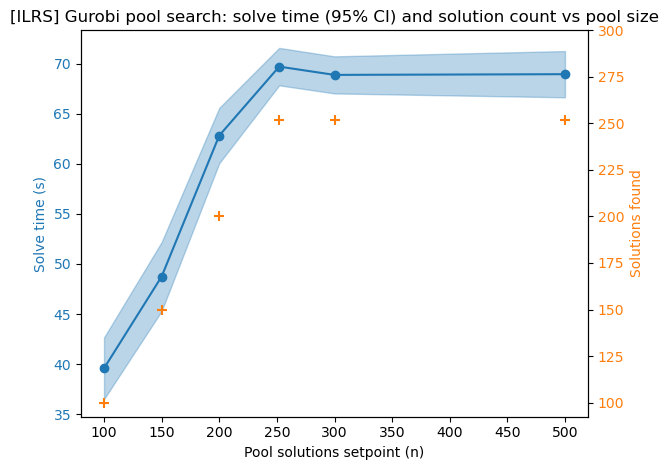

In [4]:
# Replicate plot: solve time with 95% CI, solution count on secondary axis
result_dir = script_dir / "result_gurobi" / "replicates"
plot_pool_replicates_ci(result_dir)